In [12]:
import os 
import json
import pandas as pd
import numpy as np
import glob

In [13]:
plog_paths = glob.glob('../plogs/*/*/*/*.json')

In [14]:
plogs = []
for i, plog_path in enumerate(plog_paths):
    card_nm, _, _, plog_info = plog_path.split('/')[-4:]
    model_nm, h, w, trares, testres, clevel, mlevel = plog_info.split('.')[0].split('-')
    if mlevel[2:] == 'x':
        mlevel = 'null'
    elif mlevel[2:] == '0':
        mlevel = 'diag'

    clevel = int(clevel[2:])
    trares = int(trares)
    testres = int(testres)
    
    with open(plog_path, 'r') as f:
        plog = json.load(f)

    plog['card'] = card_nm
    plog['model'] = model_nm
    plog['coarse_level'] = clevel
    plog['resolution'] = trares 
    plog['residual'] = mlevel
    plog['model_FLOPs'] = float(plog['model_FLOPs'][:-1])
    plog['model_nparam'] = float(plog['model_nparam'][:-1])
    

    plogs.append(plog) 

In [15]:
plog_df = pd.DataFrame(plogs)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns 

#### Train Time on different residual type

In [17]:
import matplotlib.pyplot as plt 
import matplotlib as mpl

In [40]:
plog

{'bsz': 16,
 'tra_time': 0.005621991056328018,
 'infer_time': 0.0022892594306419298,
 'tra_mem': 3170.0,
 'infer_mem': 1582.0,
 'model_FLOPs': 8.40853,
 'model_nparam': 1.08205,
 'card': 'V100-DGXS-32GB',
 'model': 'lno1d',
 'coarse_level': 0,
 'resolution': 4096,
 'residual': 'ml4'}

In [48]:
sub_df = plog_df[(plog_df.resolution == 4096) & (plog_df.residual == 'diag')]

In [57]:
sub_df.groupby(['resolution', 'model', 'coarse_level']).apply(lambda x:x)[['tra_time', 'infer_time', 'tra_mem', 'infer_mem', 'model_nparam']]

tra_time  infer_time  tra_mem  infer_mem   
resolution model coarse_level                                                 
4096       fno1d 0            306  0.000790    0.000264   1628.0     1294.0  \
                 1            403  0.000881    0.000286   1570.0     1280.0   
                 2            437  0.000842    0.000269   1534.0     1252.0   
                 3            414  0.000876    0.000270   1510.0     1252.0   
                 4            315  0.000826    0.000350   1512.0     1254.0   
           ft1d  0            196  0.023416    0.008073  23608.0     5608.0   
                 1            180  0.008348    0.002835   7524.0     2352.0   
                 2            268  0.003777    0.001273   3288.0     1706.0   
                 3            206  0.002577    0.000847   2226.0     1298.0   
                 4            258  0.002461    0.000729   1912.0     1264.0   
           gt1d  0            0    0.006039    0.001941   3340.0     1514.0   
                 1            80   0.003894    0.001257   2536.0     1330.0   
                 2            123  0.002782    0.000927   2140.0     1276.0   
                 3            130  0.002385    0.000811   1974.0     1266.0   
                 4            60   0.002364    0.000762   1842.0     1258.0   
           lno1d 0            572  0.003997    0.001743   2994.0     1406.0   
                 1            581  0.002620    0.001037   2274.0     1296.0   
                 2            570  0.001935    0.000678   1930.0     1262.0   
                 3            579  0.001738    0.000503   1768.0     1268.0   
                 4            513  0.001782    0.000455   1660.0     1264.0   

                                   model_nparam  
resolution model coarse_level                    
4096       fno1d 0            306       287.425  
                 1            403       287.425  
                 2            437       287.425  
                 3            414       287.425  
                 4            315       287.425  
           ft1d  0            196       329.153  
                 1            180       329.153  
                 2            268       329.153  
                 3            206       329.153  
                 4            258       329.153  
           gt1d  0            0         329.153  
                 1            80        329.153  
                 2            123       329.153  
                 3            130       329.153  
                 4            60        329.153  
           lno1d 0            572       884.417  
                 1            581       884.417  
                 2            570       884.417  
                 3            579       884.417  
                 4            513       884.417

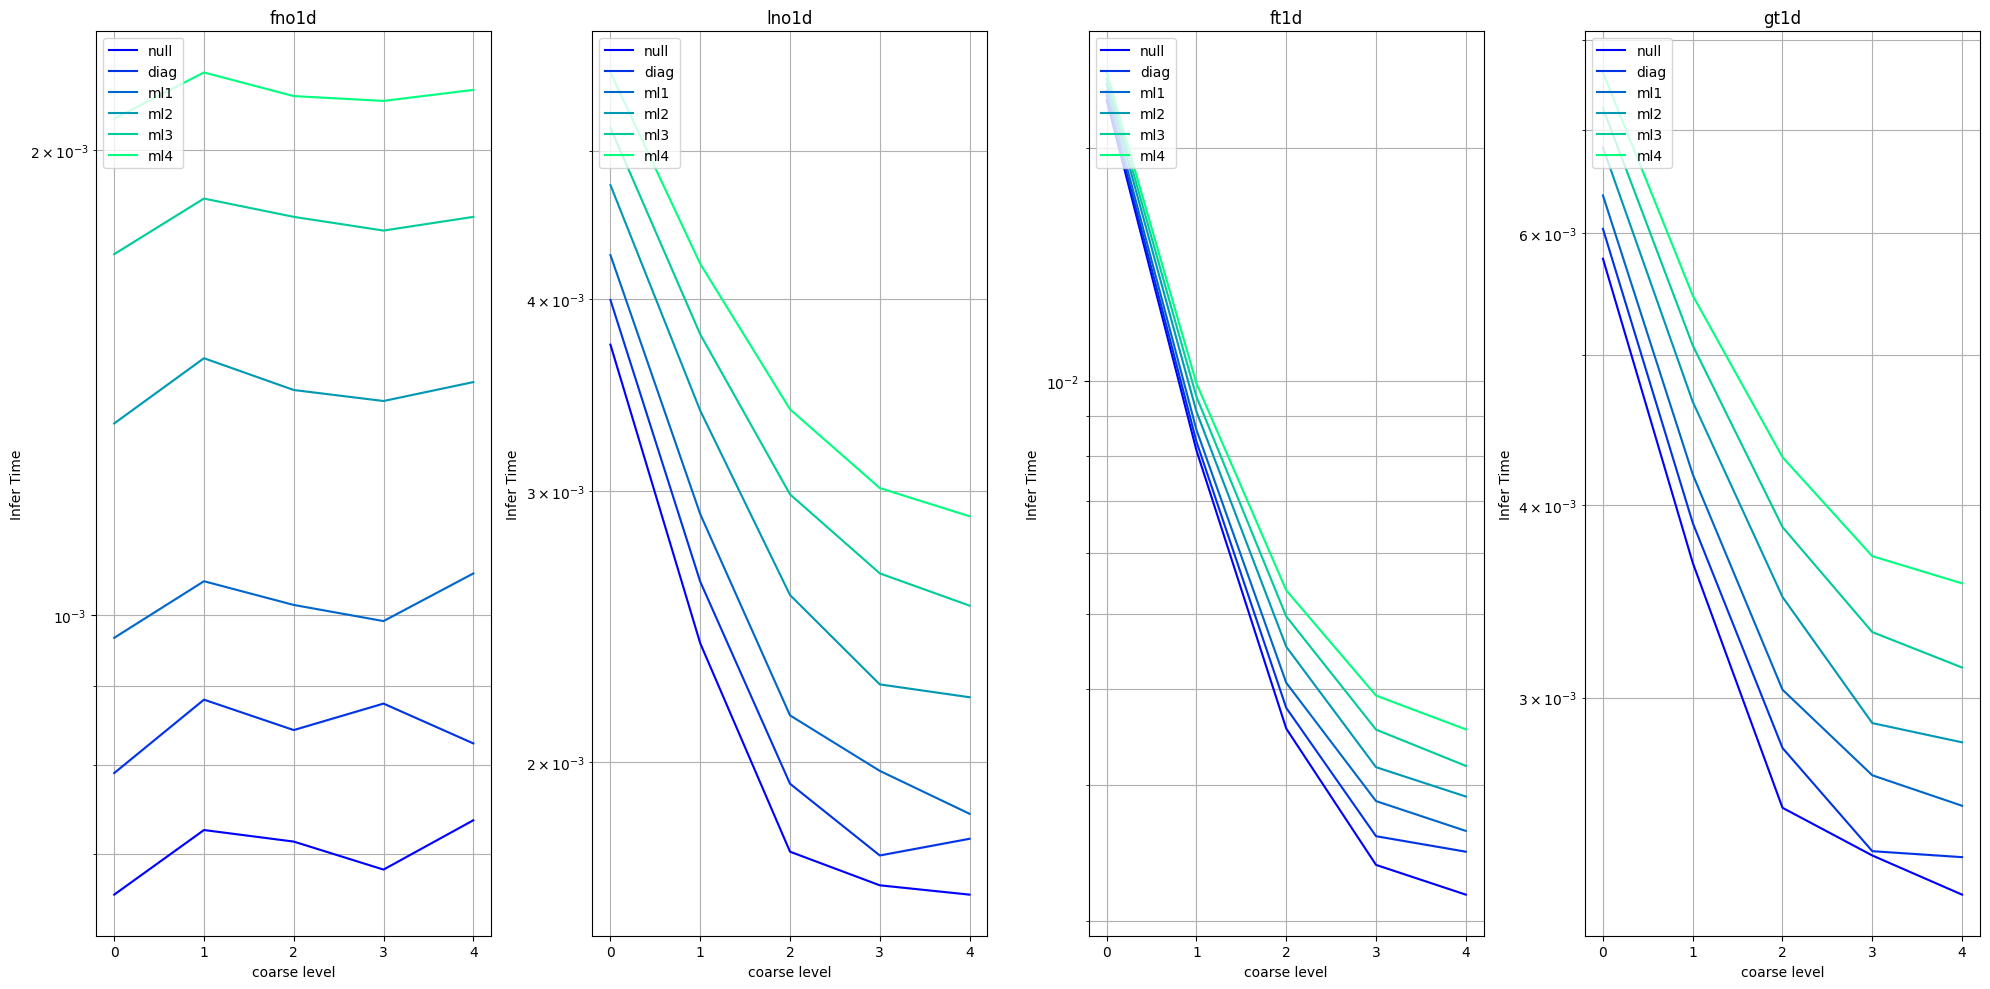

In [61]:
measure = 'tra_time'

fig, axs = plt.subplots(1, 4, figsize=(20, 10))#, sharey='row')
sub_df = plog_df[plog_df.resolution == 4096]
colors = mpl.colormaps['winter']
coarse_levels = [0, 1, 2, 3, 4]

for m, model in enumerate(['fno1d', 'lno1d', 'ft1d', 'gt1d']):
    subsub_df = sub_df[(sub_df.model == model)]            
    table_mean = subsub_df.pivot_table(values=measure, index=['coarse_level'], columns=['residual'], aggfunc=np.mean)
    table_min = subsub_df.pivot_table(values=measure, index=['coarse_level'], columns=['residual'], aggfunc=np.min)
    table_max = subsub_df.pivot_table(values=measure, index=['coarse_level'], columns=['residual'], aggfunc=np.max)
    
    for r, residual in enumerate(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']):
        axs[m].plot(table_mean.index, table_mean[[residual]].values.reshape(-1), "-",color=colors(r*0.2), label=residual)
        axs[m].fill_between(table_mean.index, 
                                table_min[[residual]].values.reshape(-1),
                                table_max[[residual]].values.reshape(-1), color=colors(r*0.2), alpha=0.1)
        
    axs[m].set_xticks(coarse_levels)
    axs[m].set_xticklabels(coarse_levels)
    axs[m].set_title("{:}".format(model))
    axs[m].set_yscale('log')
    axs[m].grid(axis='both', which='both')
    axs[m].legend(loc='upper left')
    axs[m].set_xlabel('coarse level')
    axs[m].set_ylabel('Infer Time')
        
fig.tight_layout()

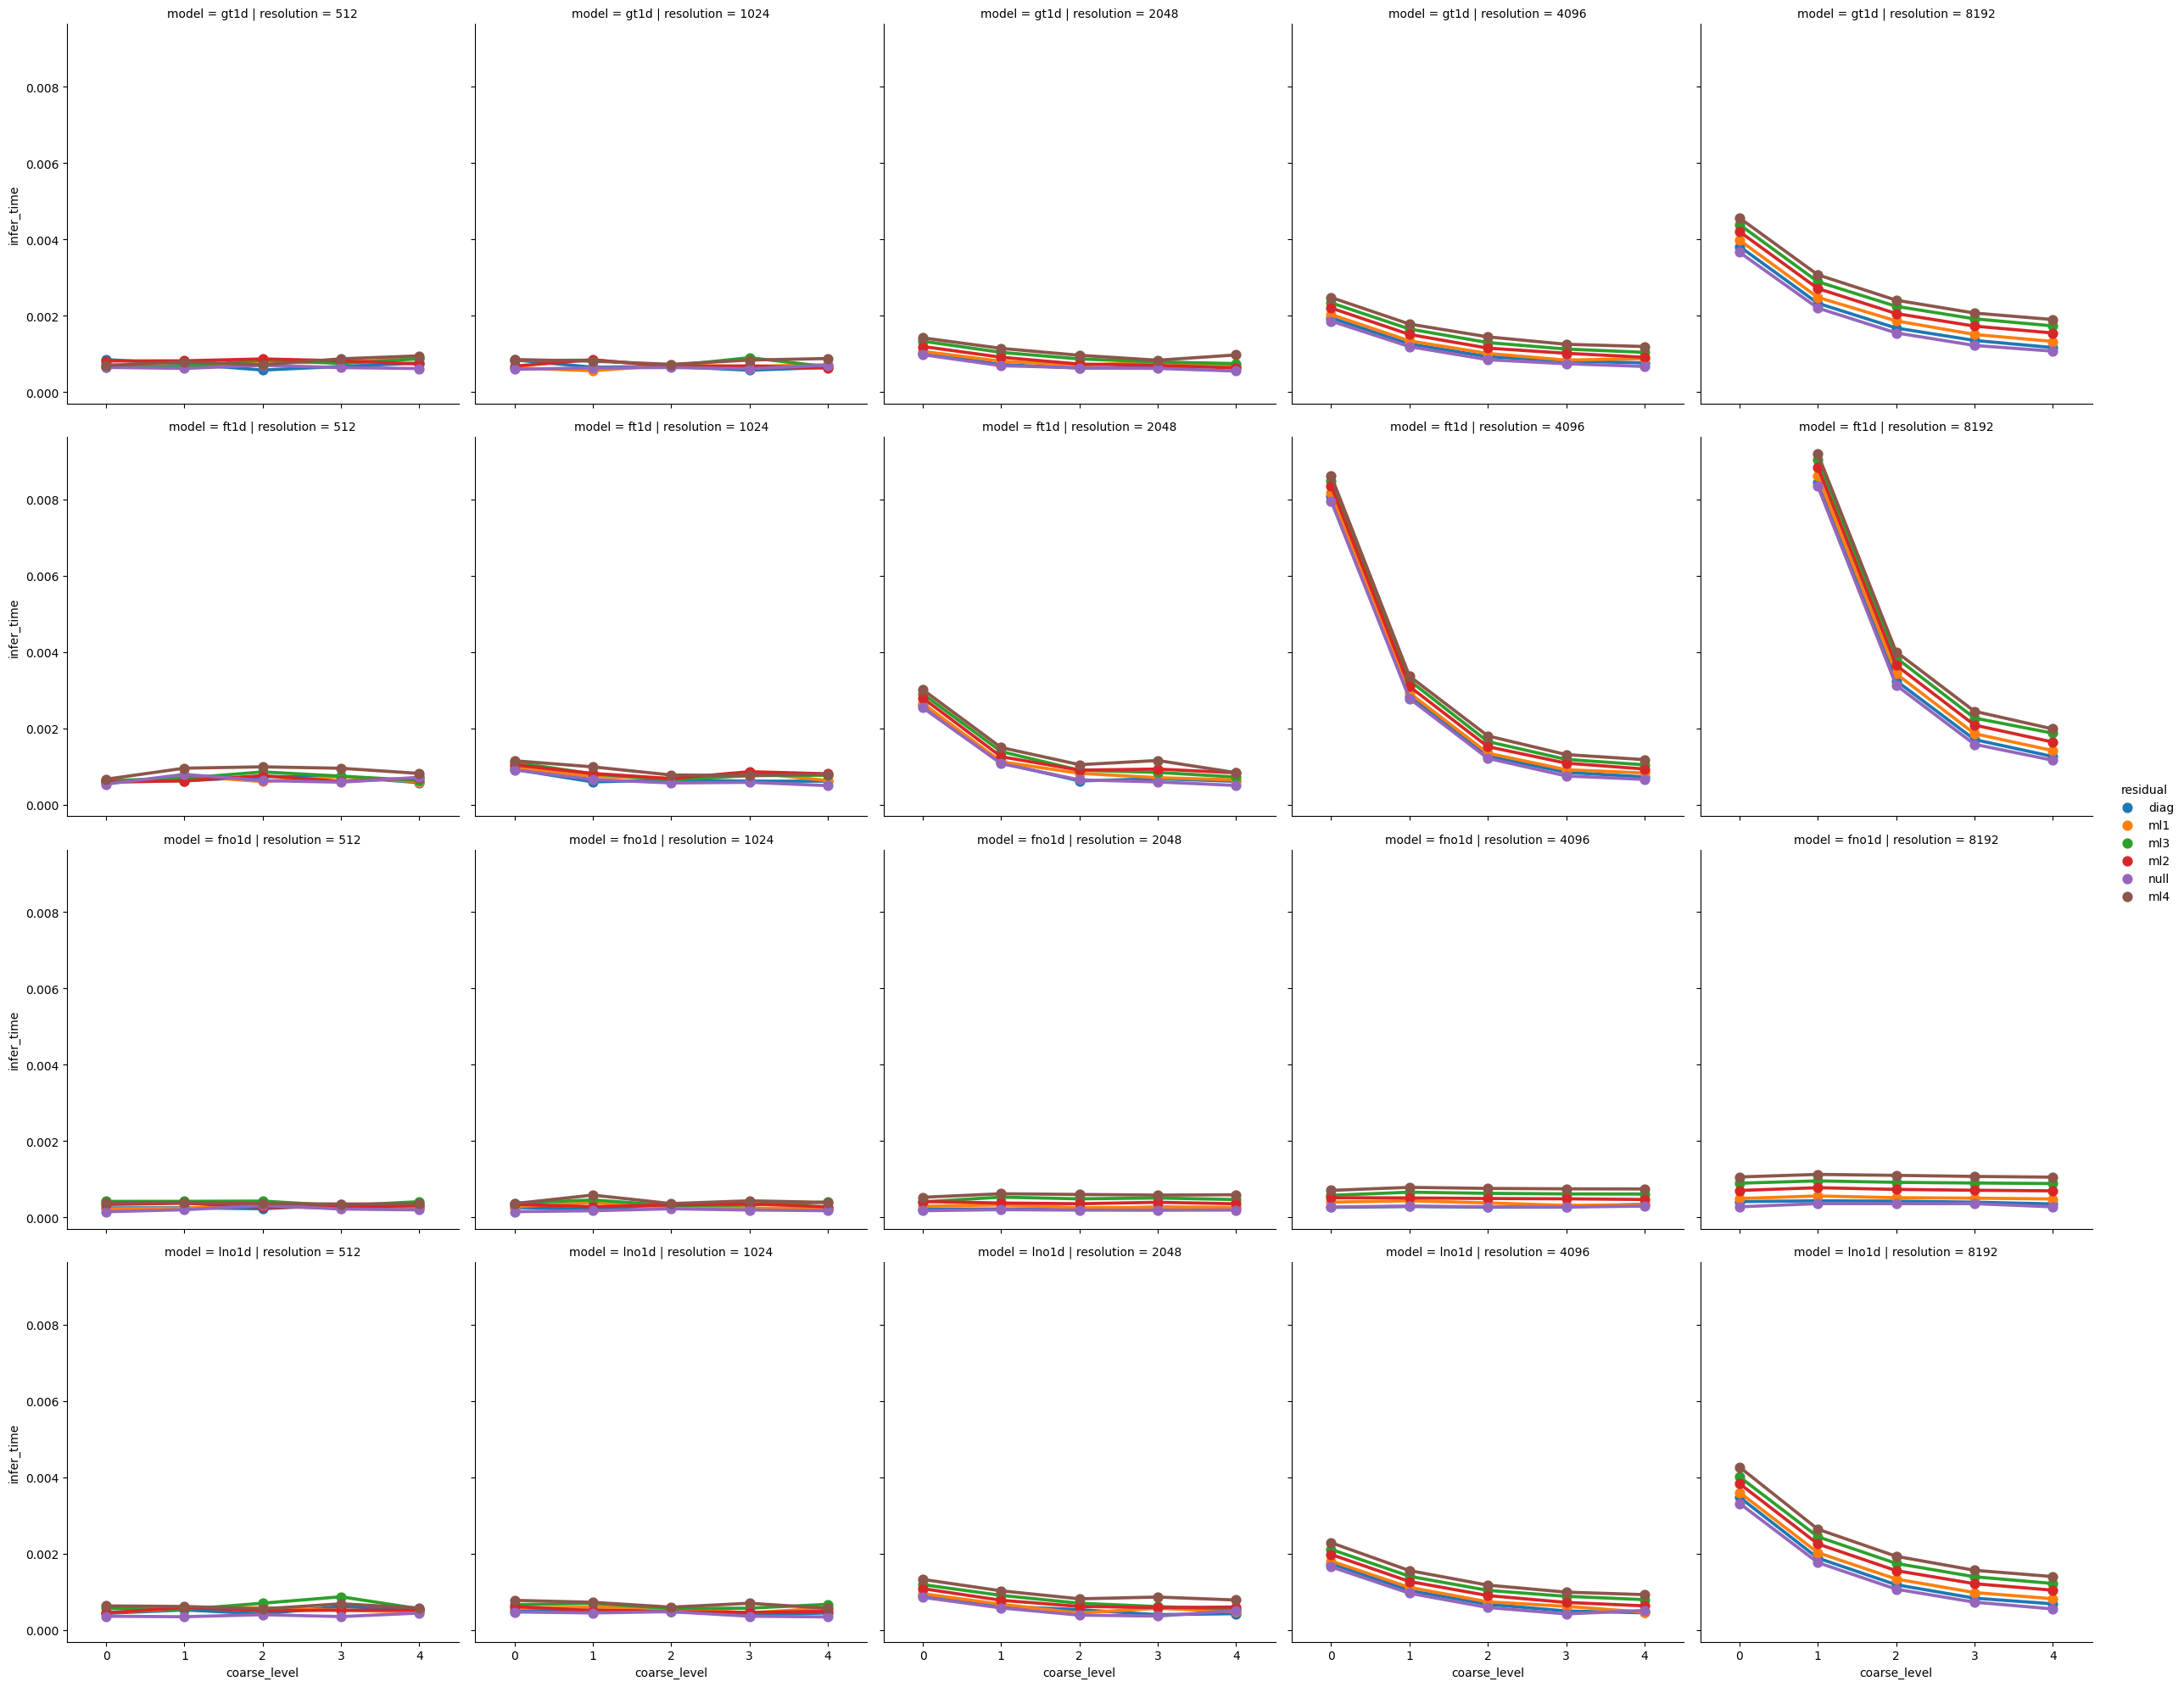

In [7]:
g = sns.catplot(data=plog_df, x='coarse_level', y='infer_time', hue='residual', col='resolution', row='model', kind='point')
# g.set(yscale='log')

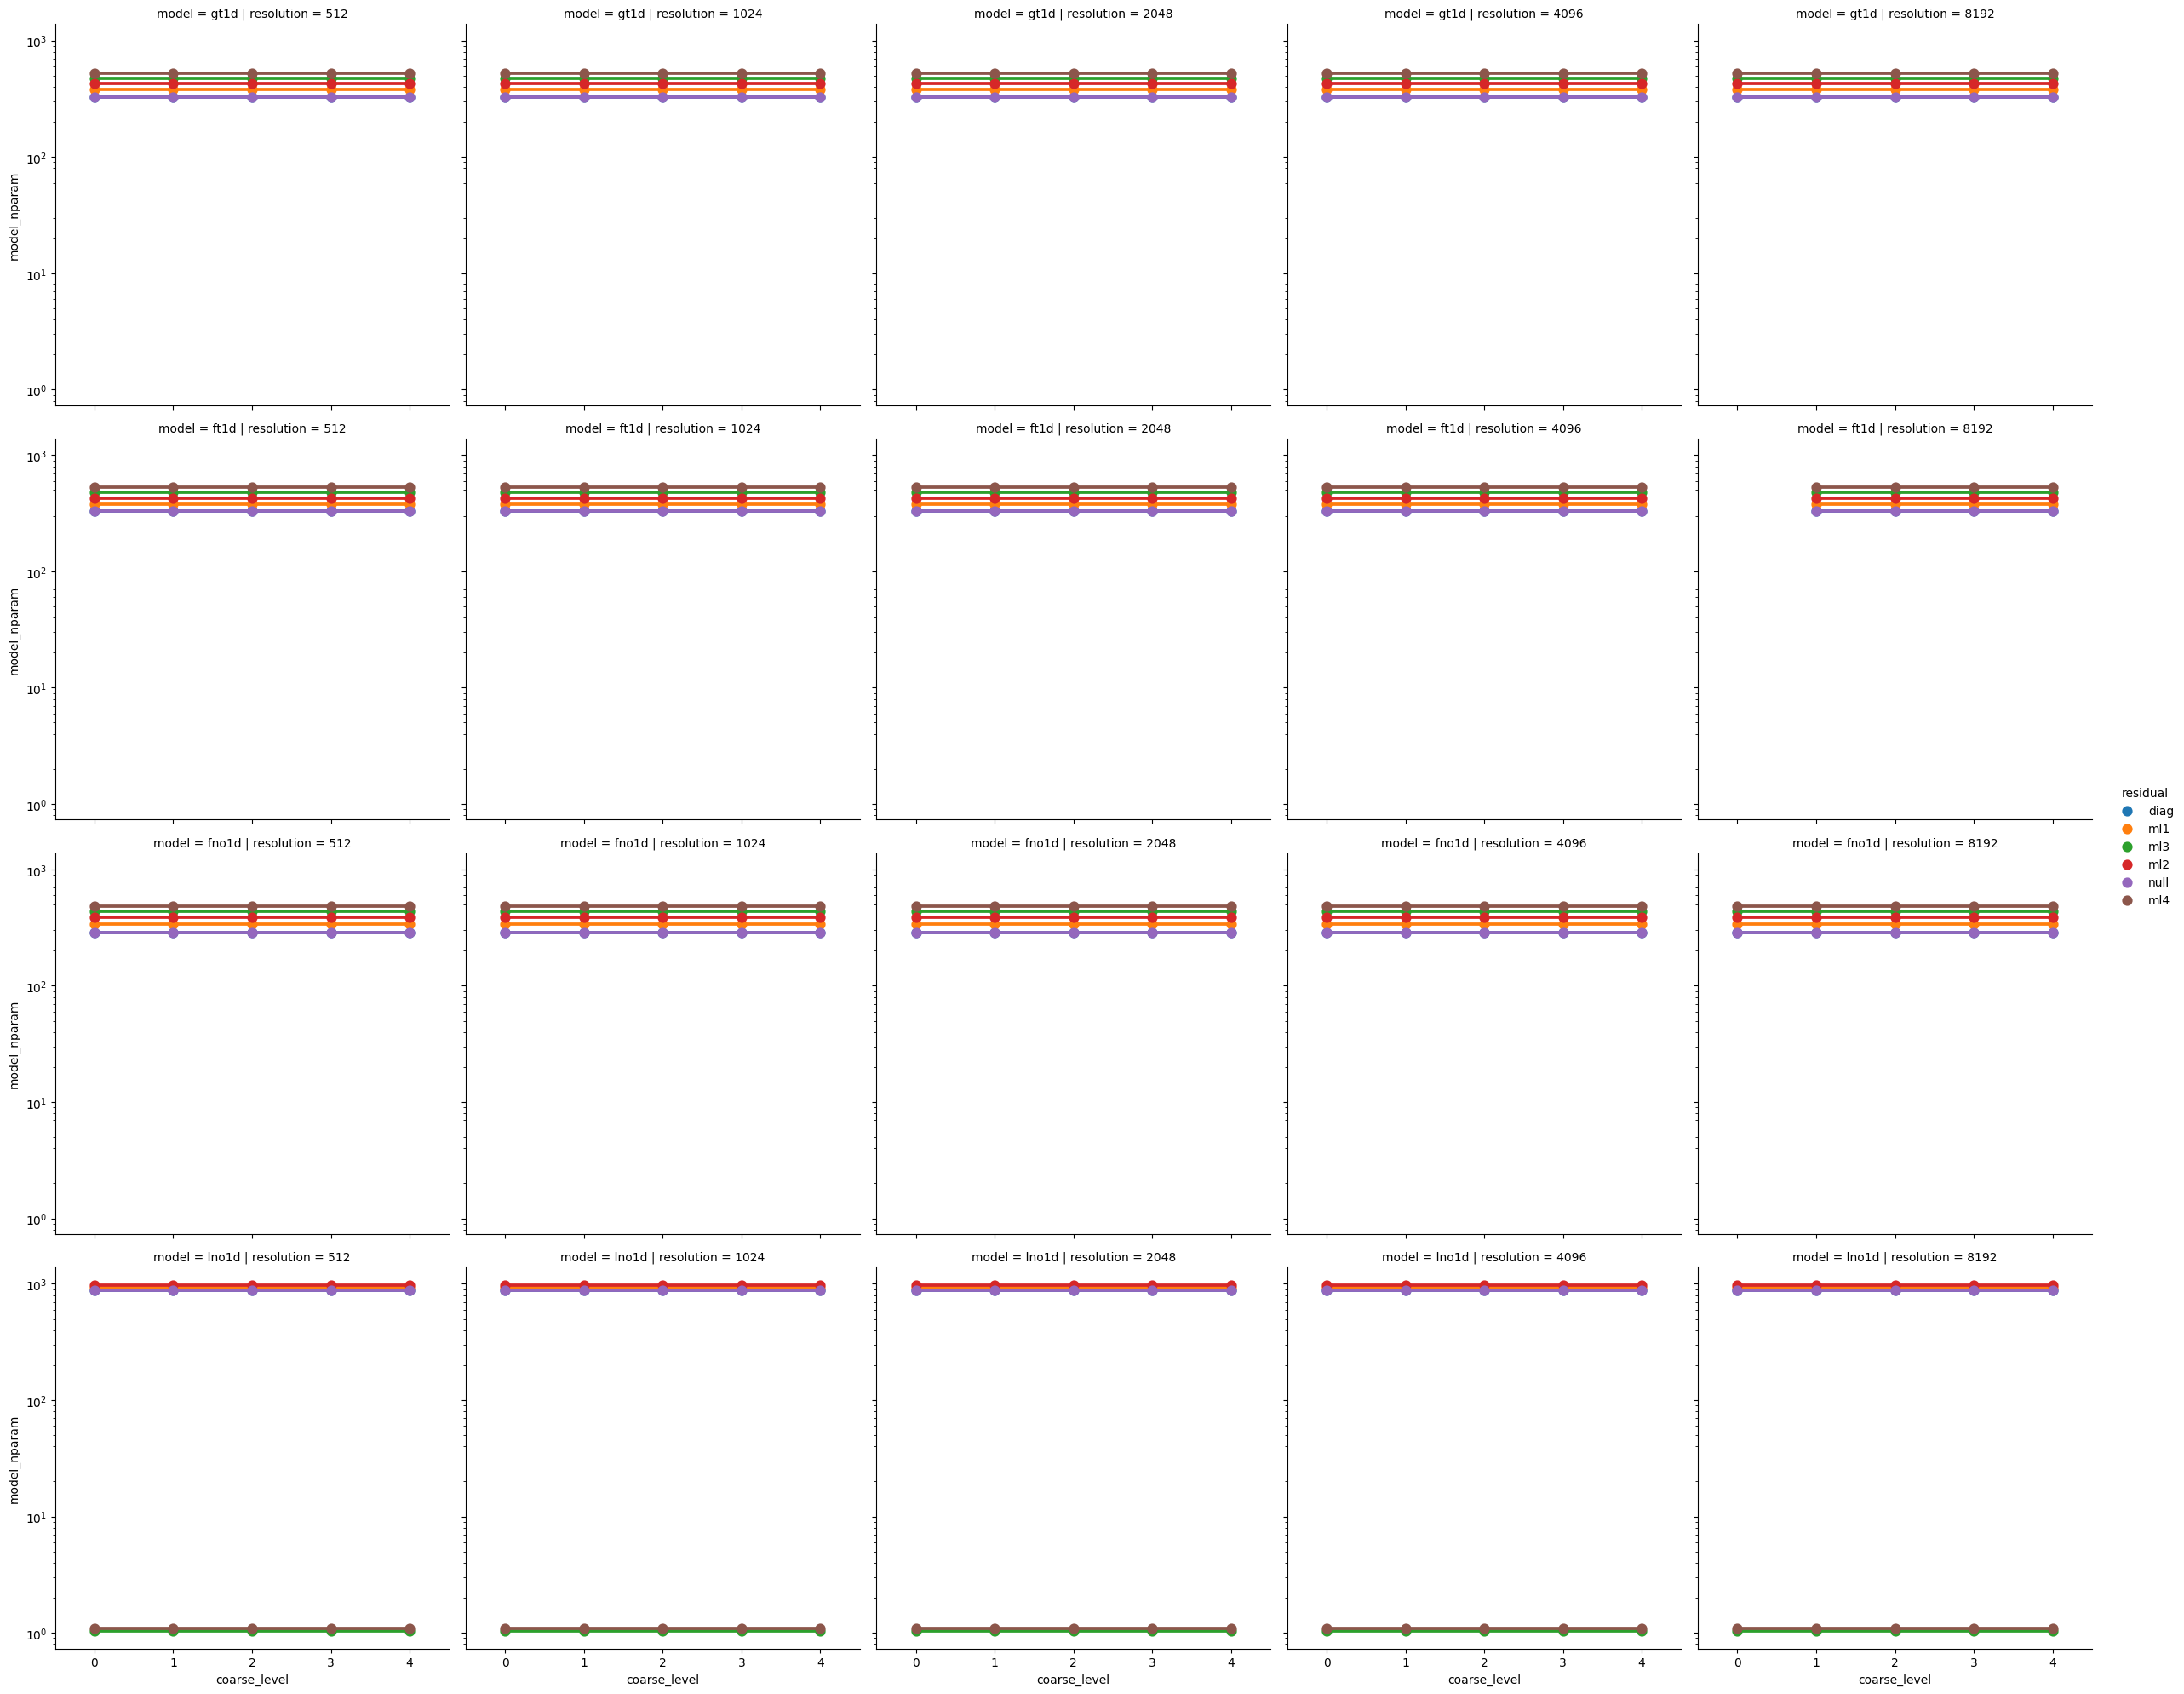

In [12]:
g = sns.catplot(data=plog_df, x='coarse_level', y='model_nparam', hue='residual', col='resolution', row='model', kind='point')
g.set(yscale='log')

In [9]:
# sub_df = plog_df[plog_df.model == 'ft1d']
# g = sns.catplot(data=sub_df, x='coarse_level', y='infer_time', hue='residual', col='resolution', kind='point')